DEMOSTRACIÓN DE LA DIFERENCIA DE ENERGÍA EN EL ALGORITMO DE METRÓPOLIS



Para implementar eficientemente la dinámica de Metrópolis en el modelo de Hopfield, calculamos la variación local de energía $\Delta H = H(s') - H(s)$ cuando una única neurona en la posición $(i,j)$ intenta cambiar su estado ($s_{i,j} \rightarrow s'_{i,j}$), manteniendo el resto de la red completamente inalterada.


El Hamiltoniano total del sistema se define como:
\begin{equation}
H(s) = -\frac{1}{2}\sum_{i=1}^{N}\sum_{j=1}^{N}\sum_{k=1}^{N}\sum_{l=1}^{N}\omega_{ij,kl}s_{i,j}s_{k,l} + \sum_{i=1}^{N}\sum_{j=1}^{N}\theta_{i,j}s_{i,j}
\end{equation}

Por otro lado:\\

\begin{equation}
H(s_{i,j}) = -s_{i,j}\sum_{k=1}^{N}\sum_{l=1}^{N}\omega_{ij,kl}s_{k,l} + \theta_{i,j}s_{i,j}
\end{equation}

Sacando factor común la variable de estado $s_{i,j}$, obtenemos:
\begin{equation}
H(s_{i,j}) = s_{i,j} \left( \theta_{i,j} - \sum_{k=1}^{N}\sum_{l=1}^{N}\omega_{ij,kl}s_{k,l} \right)
\end{equation}

Donde:\\
\begin{equation}
\theta_{i,j} = \frac{1}{2}\sum_{k=1}^{N}\sum_{l=1}^{N}\omega_{ij,kl}
\end{equation}

Sustituyendo:
\begin{align*}
H_{\text{local}}(s_{i,j}) &= s_{i,j} \left( \frac{1}{2}\sum_{k=1}^{N}\sum_{l=1}^{N}\omega_{ij,kl} - \sum_{k=1}^{N}\sum_{l=1}^{N}\omega_{ij,kl}s_{k,l} \right) \\
&= s_{i,j} \sum_{k=1}^{N}\sum_{l=1}^{N} \omega_{ij,kl} (0.5 - s_{k,l})
\end{align*}

\subsection*{Paso 3: Cálculo de la variación de energía $\Delta H$}
La variación neta de energía al invertir el estado de la neurona $(i,j)$ se calcula evaluando la diferencia entre el estado propuesto $s'_{i,j}$ y el actual $s_{i,j}$:
\begin{equation}
\Delta H = H(s'_{i,j}) - H(s_{i,j})
\end{equation}

Sustituyendo:
\begin{equation}
\begin{split}
\Delta H &= s'_{i,j} \sum_{k=1}^{N}\sum_{l=1}^{N} \omega_{ij,kl} (0.5 - s_{k,l}) - s_{i,j} \sum_{k=1}^{N}\sum_{l=1}^{N} \omega_{ij,kl} (0.5 - s_{k,l}) \\
&= (s'_{i,j} - s_{i,j}) \sum_{k=1}^{N}\sum_{l=1}^{N} \omega_{ij,kl} (0.5 - s_{k,l})
\end{split}
\end{equation}

Como $s_{i,j} \in \{0, 1\}$, evaluamos los dos escenarios posibles:

\vspace{0.3cm}
\noindent \textbf{Caso 1: Si la neurona estaba activa (\texttt{S[i][j] == 1})}

El estado inicial es $s_{i,j} = 1$ y el estado final es $s'_{i,j} = 0$. Por lo tanto, el diferencial de estados es $(s'_{i,j} - s_{i,j}) = 0 - 1 = -1$. Al sustituir en la ecuación e introducir el signo negativo dentro del paréntesis, se obtiene:
\begin{equation*}
\Delta H = -\sum_{k=1}^{N}\sum_{l=1}^{N} \omega_{ij,kl}(0.5 - s_{k,l}) = \sum_{k=1}^{N}\sum_{l=1}^{N}\omega_{ij,kl}(s_{k,l} - 0.5)
\end{equation*}


Caso 2: Si la neurona estaba inactiva (\texttt{S[i][j] == 0})

El estado inicial es $s_{i,j} = 0$ y el estado final tras la actualización es $s'_{i,j} = 1$. El diferencial de estados es $(s'_{i,j} - s_{i,j}) = 1 - 0 = 1$. Sustituyendo:
\begin{equation}
\Delta H = \sum_{k=1}^{N}\sum_{l=1}^{N} \omega_{ij,kl} (0.5 - s_{k,l})
\end{equation}

EJERCICIO 1

Representación de como partiendo de un microestado aleatorio, pasado una cierta cantidad de pasos, se llega al patrón de mínima energía que es el de la bola del mundo, lo mismo para una configuración deformada. Para una temperatura T

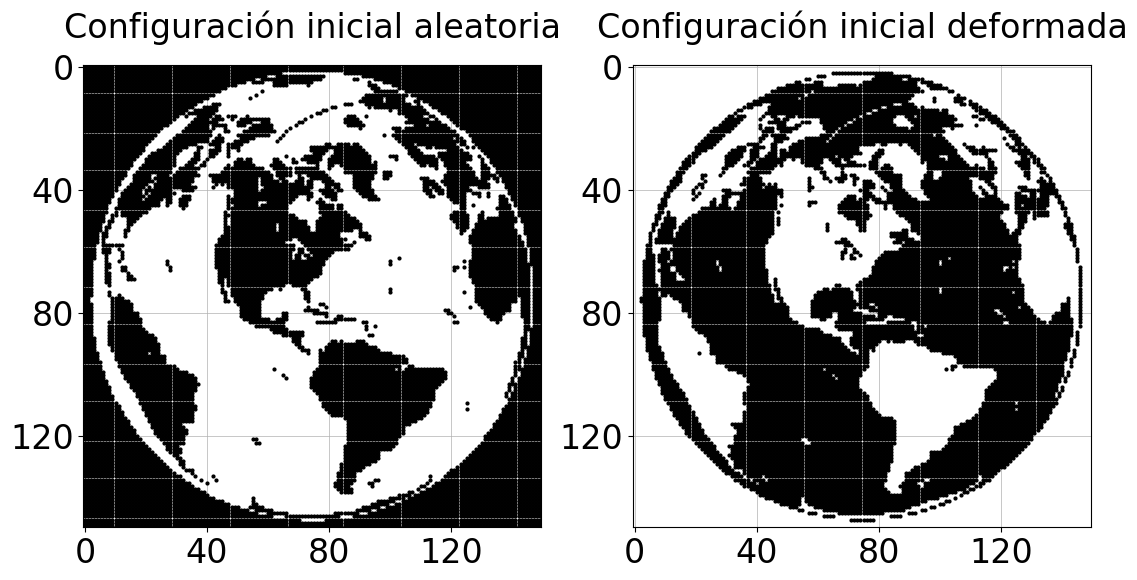

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Cargamos los datos
datos_aleatorio = np.loadtxt("neuronas_aleatorios.txt")
datos_deformado = np.loadtxt("deformado.txt")

# La matriz ya viene regular: 2850 filas x 150 columnas = 19 estados de 150x150
N = 150
Neuronas_aleatorio = datos_aleatorio.reshape(-1, N, N)
Neuronas_deformado = datos_deformado.reshape(-1, N, N)

# Creamos la figura y el eje para la animación
fig, ax = plt.subplots(1,2,figsize=(13, 6))
fig.subplots_adjust(wspace=0.2, hspace=0.3) # Ajustamos el espacio entre subplots

ax[0].set_xlim(-0.5, N - 0.5)
ax[0].set_ylim(-0.5, N - 0.5)
ax[0].invert_yaxis() # Invertir el eje para que el origen esté en la parte superior izquierda
ax[0].set_xticks(np.arange(0, N, 40))
ax[0].set_yticks(np.arange(0, N, 40))
ax[0].tick_params(axis='x', labelsize=24)
ax[0].tick_params(axis='y', labelsize=24)
ax[0].grid(True, linewidth=0.5)
ax[0].set_title("Configuración inicial aleatoria", fontsize=24, pad=20)
ax[1].set_xlim(-0.5, N - 0.5)
ax[1].set_ylim(-0.5, N - 0.5)
ax[1].invert_yaxis() # Invertir el eje para que el origen esté en la parte superior izquierda
ax[1].set_xticks(np.arange(0, N, 40))
ax[1].set_yticks(np.arange(0, N, 40))
ax[1].tick_params(axis='x', labelsize=24)
ax[1].tick_params(axis='y', labelsize=24)
ax[1].grid(True, linewidth=0.5)
ax[1].set_title("Configuración inicial deformada", fontsize=24, pad=20)

# Defino líneas de la animación
line_0, = ax[0].plot([], [], marker='o', markersize=2, color='black', linestyle='None')
line_2, = ax[1].plot([], [], marker='o', markersize=2, color='black', linestyle='None')

def animate(i):
    paso = i
    line_0.set_data(np.where(Neuronas_aleatorio[paso,:,:] == 0)[1], np.where(Neuronas_aleatorio[paso,:,:] == 0)[0])
    line_2.set_data(np.where(Neuronas_deformado[paso,:,:] == 0)[1], np.where(Neuronas_deformado[paso,:,:] == 0)[0])
    
    return line_0, line_2

ani = animation.FuncAnimation(fig, animate, frames=Neuronas_aleatorio.shape[0], interval=400, blit=True) 
ani.save("Animacion_neuronas.gif", writer='pillow', dpi=150)

EJERCICIO 2

Representación para distintas temperaturas

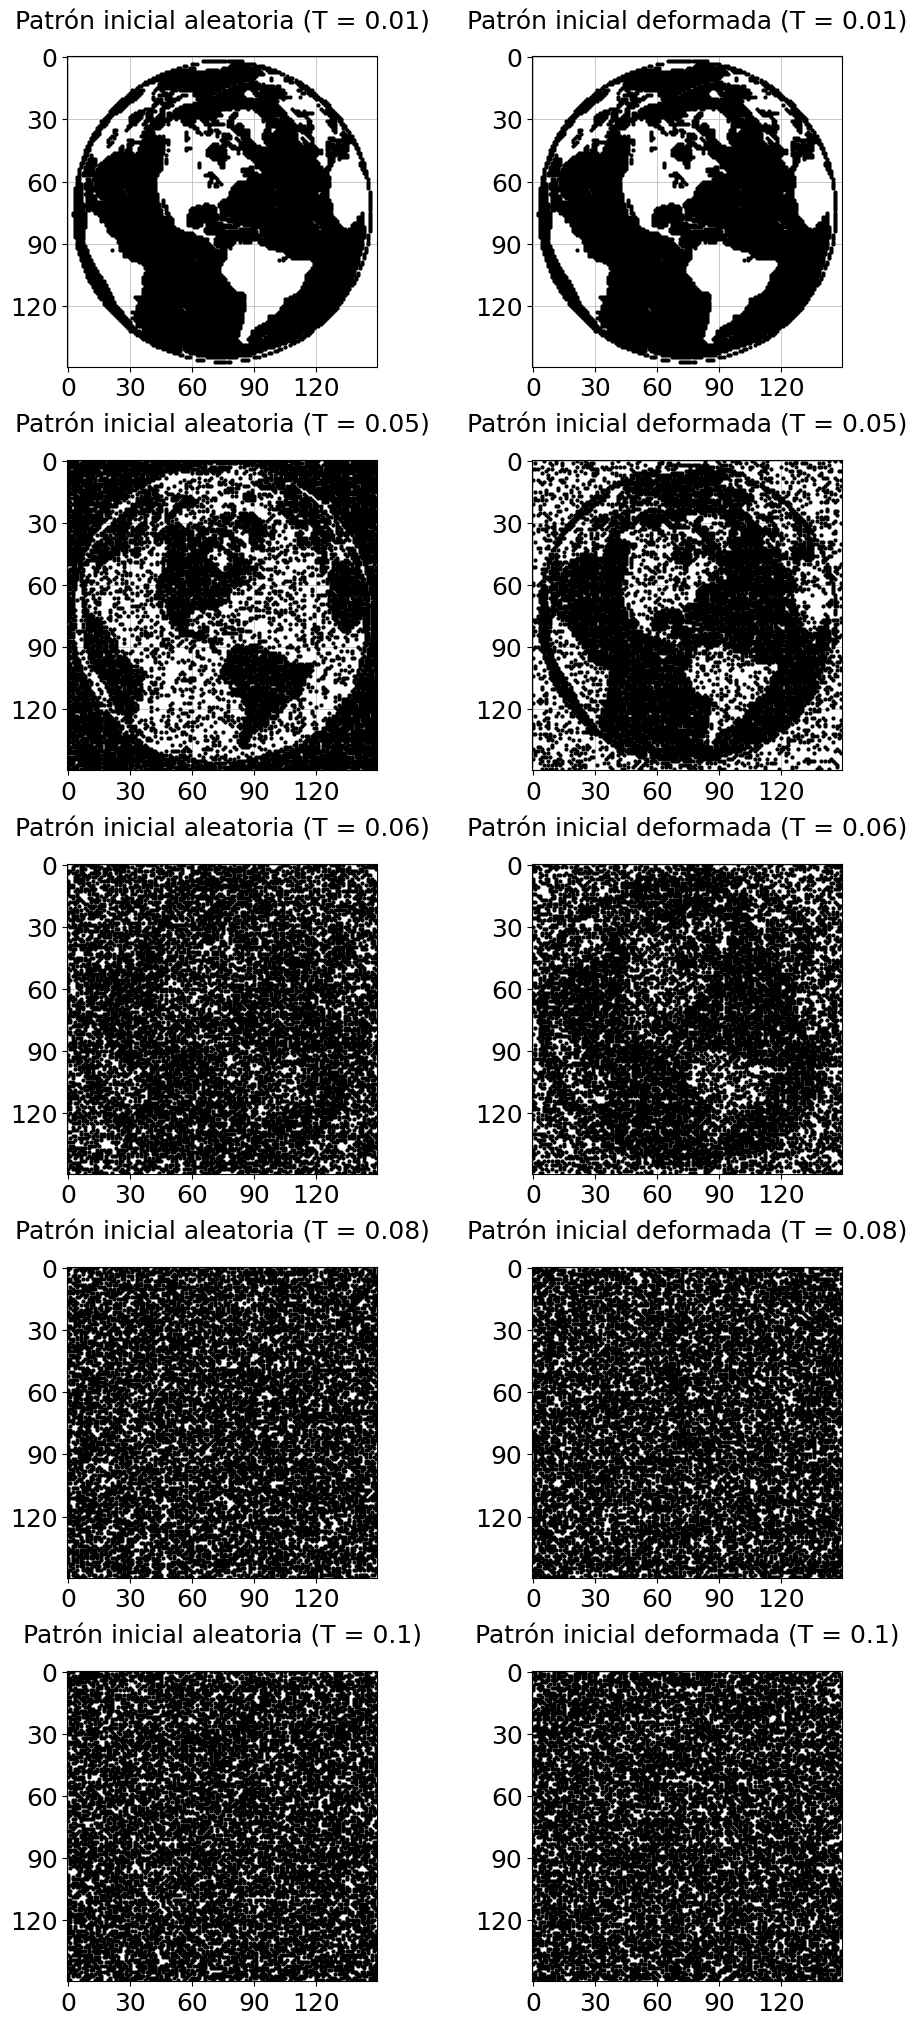

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Cargamos los datos
da_a_0_01=np.loadtxt("neuronas_aleatorios_T_0.01.txt")
da_d_0_01=np.loadtxt("deformado_T_0.01.txt")

da_a_0_05=np.loadtxt("neuronas_aleatorios_T_0.05.txt")
da_d_0_05=np.loadtxt("deformado_T_0.05.txt")

da_a_0_06=np.loadtxt("neuronas_aleatorios_T_0.06.txt")
da_d_0_06=np.loadtxt("deformado_T_0.06.txt")

da_a_0_08=np.loadtxt("neuronas_aleatorios_T_0.08.txt")
da_d_0_08=np.loadtxt("deformado_T_0.08.txt")

da_a_0_1=np.loadtxt("neuronas_aleatorios_T_0.1.txt")
da_d_0_1=np.loadtxt("deformado_T_0.1.txt")


# La matriz ya viene regular: 2850 filas x 150 columnas = 19 estados de 150x150
N = 150

d_a_0_01 = da_a_0_01.reshape(-1, N, N)
d_d_0_01 = da_d_0_01.reshape(-1, N, N)

d_a_0_05= da_a_0_05.reshape(-1, N, N)
d_d_0_05= da_d_0_05.reshape(-1, N, N)

d_a_0_06= da_a_0_06.reshape(-1, N, N)
d_d_0_06= da_d_0_06.reshape(-1, N, N)


d_a_0_08= da_a_0_08.reshape(-1, N, N)
d_d_0_08= da_d_0_08.reshape(-1, N, N)

d_a_0_1= da_a_0_1.reshape(-1, N, N)
d_d_0_1= da_d_0_1.reshape(-1, N, N)


# Creamos la figura y el eje para la animación

fig, ax = plt.subplots(5, 2, figsize=(10, 25))
fig.subplots_adjust(wspace=0.5, hspace=0.3) # Ajustamos el espacio entre subplots

for i in range(0, 5):
    for j in range(0, 2):
        ax[i][j].set_xlim(-0.5, N - 0.5)
        ax[i][j].set_ylim(-0.5, N - 0.5)
        ax[i][j].invert_yaxis() # Invertir el eje para que el origen esté en la parte superior izquierda
        ax[i][j].set_xticks(np.arange(0, N, 30))
        ax[i][j].set_yticks(np.arange(0, N, 30))
        ax[i][j].tick_params(axis='x', labelsize=18)
        ax[i][j].tick_params(axis='y', labelsize=18)
        ax[i][j].grid(True, linewidth=0.5)

ax[0][0].set_title("Patrón inicial aleatoria (T = 0.01)", fontsize=18, pad=20)
ax[1][0].set_title("Patrón inicial aleatoria (T = 0.05)", fontsize=18, pad=20)
ax[2][0].set_title("Patrón inicial aleatoria (T = 0.06)", fontsize=18, pad=20)
ax[3][0].set_title("Patrón inicial aleatoria (T = 0.08)", fontsize=18, pad=20)
ax[4][0].set_title("Patrón inicial aleatoria (T = 0.1)", fontsize=18, pad=20)

ax[0][1].set_title("Patrón inicial deformada (T = 0.01)", fontsize=18, pad=20)
ax[1][1].set_title("Patrón inicial deformada (T = 0.05)", fontsize=18, pad=20)
ax[2][1].set_title("Patrón inicial deformada (T = 0.06)", fontsize=18, pad=20)
ax[3][1].set_title("Patrón inicial deformada (T = 0.08)", fontsize=18, pad=20)
ax[4][1].set_title("Patrón inicial deformada (T = 0.1)", fontsize=18, pad=20)



# Defino líneas de la animación b y n (blanco y negro)
line_a_0_01, = ax[0][0].plot([], [], marker='o', markersize=2, color='black', linestyle='None')
line_a_0_05, = ax[1][0].plot([], [], marker='o', markersize=2, color='black', linestyle='None')
line_a_0_06, = ax[2][0].plot([], [], marker='o', markersize=2, color='black', linestyle='None')
line_a_0_08, = ax[3][0].plot([], [], marker='o', markersize=2, color='black', linestyle='None')
line_a_0_1, = ax[4][0].plot([], [], marker='o', markersize=2, color='black', linestyle='None')

line_d_0_01, = ax[0][1].plot([], [], marker='o', markersize=2, color='black', linestyle='None')
line_d_0_05, = ax[1][1].plot([], [], marker='o', markersize=2, color='black', linestyle='None')
line_d_0_06, = ax[2][1].plot([], [], marker='o', markersize=2, color='black', linestyle='None')
line_d_0_08, = ax[3][1].plot([], [], marker='o', markersize=2, color='black', linestyle='None')
line_d_0_1, = ax[4][1].plot([], [], marker='o', markersize=2, color='black', linestyle='None')

def animate(i):
    paso = i

    line_a_0_01.set_data(np.where(d_a_0_01[paso,:,:] == 0)[1], np.where(d_a_0_01[paso,:,:] == 0)[0])
    line_a_0_05.set_data(np.where(d_a_0_05[paso,:,:] == 0)[1], np.where(d_a_0_05[paso,:,:] == 0)[0])
    line_a_0_06.set_data(np.where(d_a_0_06[paso,:,:] == 0)[1], np.where(d_a_0_06[paso,:,:] == 0)[0])
    line_a_0_08.set_data(np.where(d_a_0_08[paso,:,:] == 0)[1], np.where(d_a_0_08[paso,:,:] == 0)[0])
    line_a_0_1.set_data(np.where(d_a_0_1[paso,:,:] == 0)[1], np.where(d_a_0_1[paso,:,:] == 0)[0])
    
    line_d_0_01.set_data(np.where(d_d_0_01[paso,:,:] == 0)[1], np.where(d_d_0_01[paso,:,:] == 0)[0])
    line_d_0_05.set_data(np.where(d_d_0_05[paso,:,:] == 0)[1], np.where(d_d_0_05[paso,:,:] == 0)[0])
    line_d_0_06.set_data(np.where(d_d_0_06[paso,:,:] == 0)[1], np.where(d_d_0_06[paso,:,:] == 0)[0])
    line_d_0_08.set_data(np.where(d_d_0_08[paso,:,:] == 0)[1], np.where(d_d_0_08[paso,:,:] == 0)[0])
    line_d_0_1.set_data(np.where(d_d_0_1[paso,:,:] == 0)[1], np.where(d_d_0_1[paso,:,:] == 0)[0])
    

    return line_a_0_1, line_a_0_01, line_a_0_05, line_a_0_06, line_a_0_08, line_d_0_01, line_d_0_05, line_d_0_06, line_d_0_08

ani = animation.FuncAnimation(fig, animate, frames=d_a_0_1.shape[0], interval=400, blit=True) 
ani.save("Animacion_neuronas_temperaturas.gif", writer='pillow', dpi=150)

EJERCICIO 3

Representación varios patrones iniciales a una temperatura dada

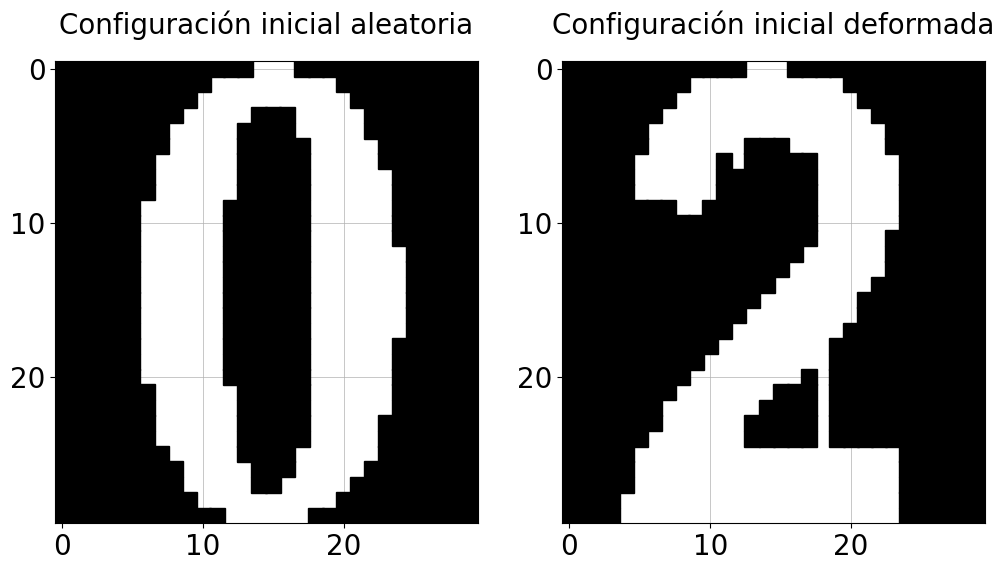

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Cargamos los datos
datos_aleatorio = np.loadtxt("neuronas_aleatorios_varios_patrones_m.txt")
datos_deformado = np.loadtxt("deformado_varios_patrones_m.txt")

# La matriz ya viene regular: 2850 filas x 150 columnas = 19 estados de 150x150
N = 30
Neuronas_aleatorio = datos_aleatorio.reshape(-1, N, N)
Neuronas_deformado = datos_deformado.reshape(-1, N, N)

# Creamos la figura y el eje para la animación
fig, ax = plt.subplots(1,2,figsize=(12, 6))
fig.subplots_adjust(wspace=0.2, hspace=0.3) # Ajustamos el espacio entre subplots

ax[0].set_xlim(-0.5, N - 0.5)
ax[0].set_ylim(-0.5, N - 0.5)
ax[0].invert_yaxis() # Invertir el eje para que el origen esté en la parte superior izquierda
ax[0].set_xticks(np.arange(0, N, 10))
ax[0].set_yticks(np.arange(0, N, 10))
ax[0].tick_params(axis='x', labelsize=20)
ax[0].tick_params(axis='y', labelsize=20)
ax[0].set_title("Configuración inicial aleatoria", fontsize=20, pad=20)
ax[0].grid(True, linewidth=0.5)
ax[1].set_xlim(-0.5, N - 0.5)
ax[1].set_ylim(-0.5, N - 0.5)
ax[1].invert_yaxis() # Invertir el eje para que el origen esté en la parte superior izquierda
ax[1].set_xticks(np.arange(0, N, 10))
ax[1].set_yticks(np.arange(0, N, 10))
ax[1].tick_params(axis='x', labelsize=20)
ax[1].tick_params(axis='y', labelsize=20)
ax[1].set_title("Configuración inicial deformada", fontsize=20, pad=20)
ax[1].grid(True, linewidth=0.5)

# Defino líneas de la animación
line_0, = ax[0].plot([], [], marker='s', markersize=11, color='black', linestyle='None')
line_2, = ax[1].plot([], [], marker='s', markersize=11, color='black', linestyle='None')

def animate(i):
    paso = i
    line_0.set_data(np.where(Neuronas_aleatorio[paso,:,:] == 0)[1], np.where(Neuronas_aleatorio[paso,:,:] == 0)[0])
    line_2.set_data(np.where(Neuronas_deformado[paso,:,:] == 0)[1], np.where(Neuronas_deformado[paso,:,:] == 0)[0])
    
    return line_0, line_2

ani = animation.FuncAnimation(fig, animate, frames=Neuronas_aleatorio.shape[0], interval=400, blit=True) 
ani.save("Animacion_neuronas_varios_patrones_m.gif", writer='pillow', dpi=150)

Representación varios patrones, diferente varias temperaturas

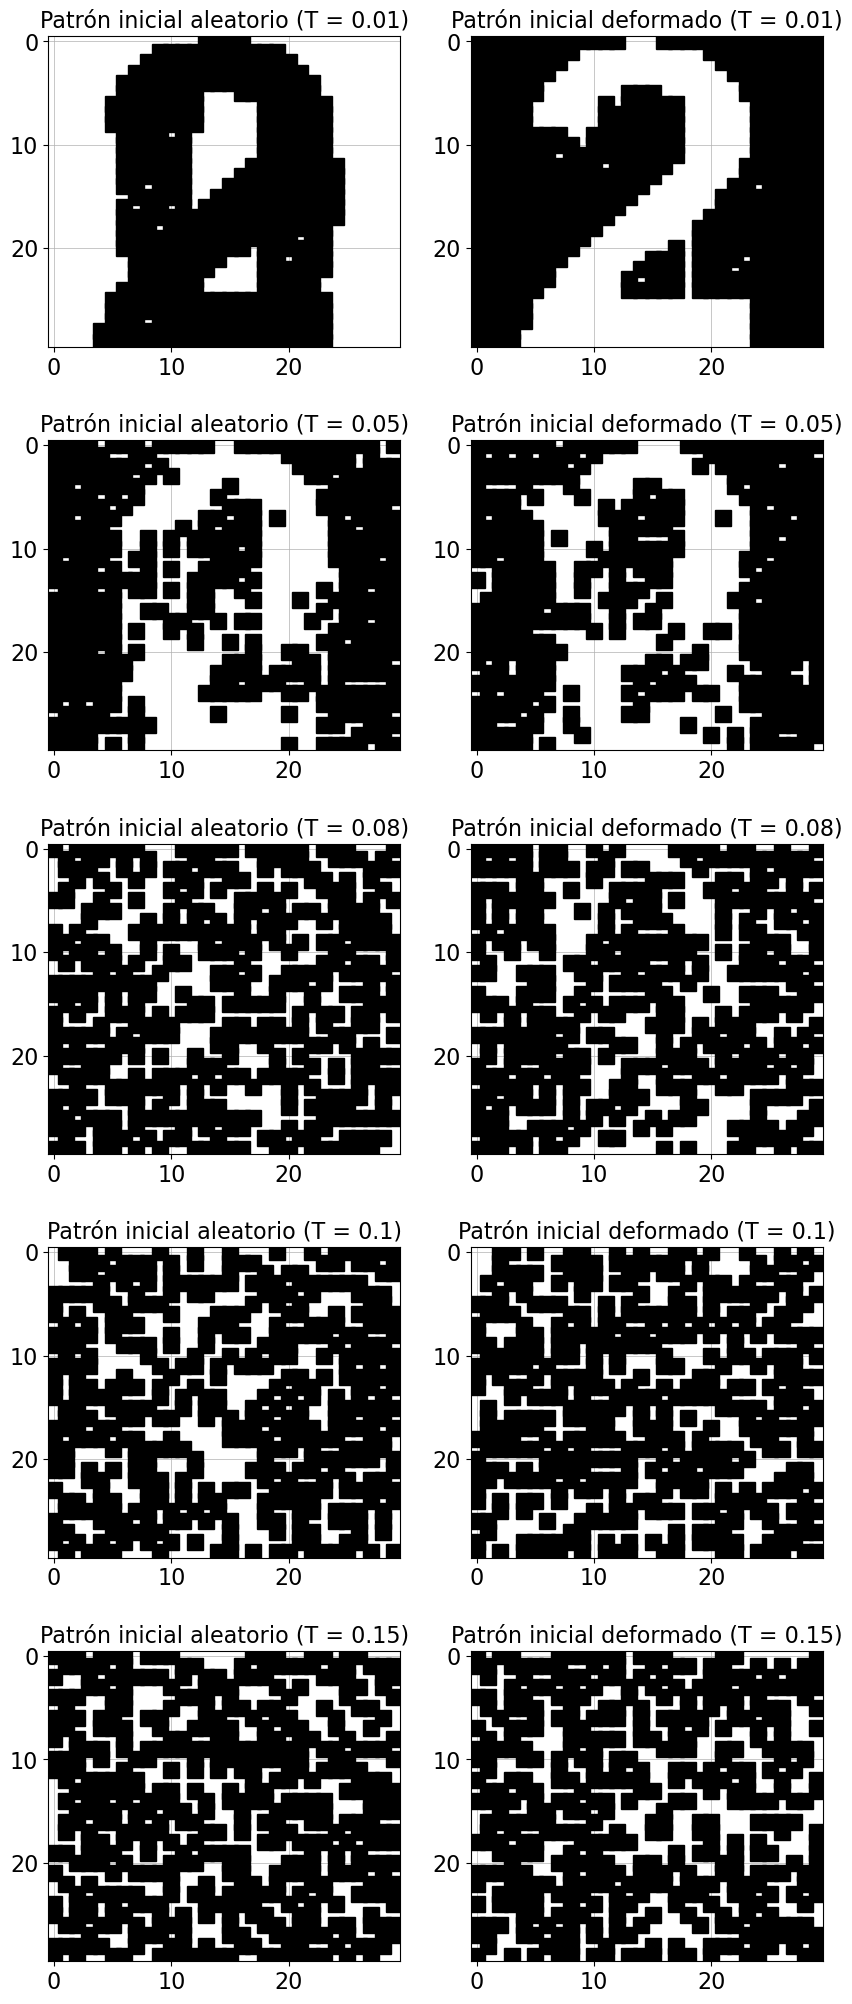

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Cargamos los datos


da_a_0_01=np.loadtxt("neuronas_aleatorios_varios_patrones_T_0.01.txt")
da_d_0_01=np.loadtxt("deformado_varios_patrones_T_0.01.txt")

da_a_0_05=np.loadtxt("neuronas_aleatorios_varios_patrones_T_0.05.txt")
da_d_0_05=np.loadtxt("deformado_varios_patrones_T_0.05.txt")

da_a_0_08=np.loadtxt("neuronas_aleatorios_varios_patrones_T_0.08.txt")
da_d_0_08=np.loadtxt("deformado_varios_patrones_T_0.08.txt")

da_a_0_1=np.loadtxt("neuronas_aleatorios_varios_patrones_T_0.1.txt")
da_d_0_1=np.loadtxt("deformado_varios_patrones_T_0.1.txt")

da_a_0_15=np.loadtxt("neuronas_aleatorios_varios_patrones_T_0.15.txt")
da_d_0_15=np.loadtxt("deformado_varios_patrones_T_0.15.txt")


# La matriz ya viene regular: 2850 filas x 150 columnas = 19 estados de 150x150
N = 30



d_a_0_01= da_a_0_01.reshape(-1, N, N)
d_d_0_01= da_d_0_01.reshape(-1, N, N)

d_a_0_05= da_a_0_05.reshape(-1, N, N)
d_d_0_05= da_d_0_05.reshape(-1, N, N)

d_a_0_08= da_a_0_08.reshape(-1, N, N)
d_d_0_08= da_d_0_08.reshape(-1, N, N)

d_a_0_1 = da_a_0_1.reshape(-1, N, N)
d_d_0_1 = da_d_0_1.reshape(-1, N, N)

d_a_0_15= da_a_0_15.reshape(-1, N, N)
d_d_0_15= da_d_0_15.reshape(-1, N, N)


# Creamos la figura y el eje para la animación

fig, ax = plt.subplots(5, 2, figsize=(10, 25))
fig.subplots_adjust(wspace=0.2, hspace=0.3) # Ajustamos el espacio entre subplots

for i in range(0, 5):
    for j in range(0, 2):
        ax[i][j].set_xlim(-0.5, N - 0.5)
        ax[i][j].set_ylim(-0.5, N - 0.5)
        ax[i][j].invert_yaxis() # Invertir el eje para que el origen esté en la parte superior izquierda
        ax[i][j].set_xticks(np.arange(0, N, 10))
        ax[i][j].set_yticks(np.arange(0, N, 10))
        ax[i][j].tick_params(axis='x', labelsize=16)
        ax[i][j].tick_params(axis='y', labelsize=16)
        ax[i][j].grid(True, linewidth=0.5)

ax[0][0].set_title("Patrón inicial aleatorio (T = 0.01)", fontsize=16)
ax[1][0].set_title("Patrón inicial aleatorio (T = 0.05)", fontsize=16)
ax[2][0].set_title("Patrón inicial aleatorio (T = 0.08)", fontsize=16)
ax[3][0].set_title("Patrón inicial aleatorio (T = 0.1)", fontsize=16)
ax[4][0].set_title("Patrón inicial aleatorio (T = 0.15)", fontsize=16)

ax[0][1].set_title("Patrón inicial deformado (T = 0.01)", fontsize=16)
ax[1][1].set_title("Patrón inicial deformado (T = 0.05)", fontsize=16)
ax[2][1].set_title("Patrón inicial deformado (T = 0.08)", fontsize=16)
ax[3][1].set_title("Patrón inicial deformado (T = 0.1)", fontsize=16)
ax[4][1].set_title("Patrón inicial deformado (T = 0.15)", fontsize=16)



# Defino líneas de la animación b y n (blanco y negro)
line_a_0_01, = ax[0][0].plot([], [], marker='s', markersize=12, color='black', linestyle='None')
line_a_0_05, = ax[1][0].plot([], [], marker='s', markersize=12, color='black', linestyle='None')
line_a_0_08, = ax[2][0].plot([], [], marker='s', markersize=12, color='black', linestyle='None')
line_a_0_1, = ax[3][0].plot([], [], marker='s', markersize=12, color='black', linestyle='None')
line_a_0_15, = ax[4][0].plot([], [], marker='s', markersize=12, color='black', linestyle='None')

line_d_0_01, = ax[0][1].plot([], [], marker='s', markersize=12, color='black', linestyle='None')
line_d_0_05, = ax[1][1].plot([], [], marker='s', markersize=12, color='black', linestyle='None')
line_d_0_08, = ax[2][1].plot([], [], marker='s', markersize=12, color='black', linestyle='None')
line_d_0_1, = ax[3][1].plot([], [], marker='s', markersize=12, color='black', linestyle='None')
line_d_0_15, = ax[4][1].plot([], [], marker='s', markersize=12, color='black', linestyle='None')

def animate(i):
    paso = i

    line_a_0_01.set_data(np.where(d_a_0_01[paso,:,:] == 0)[1], np.where(d_a_0_01[paso,:,:] == 0)[0])
    line_a_0_05.set_data(np.where(d_a_0_05[paso,:,:] == 0)[1], np.where(d_a_0_05[paso,:,:] == 0)[0])
    line_a_0_08.set_data(np.where(d_a_0_08[paso,:,:] == 0)[1], np.where(d_a_0_08[paso,:,:] == 0)[0])
    line_a_0_1.set_data(np.where(d_a_0_1[paso,:,:] == 0)[1], np.where(d_a_0_1[paso,:,:] == 0)[0])
    line_a_0_15.set_data(np.where(d_a_0_15[paso,:,:] == 0)[1], np.where(d_a_0_15[paso,:,:] == 0)[0])
    
    line_d_0_01.set_data(np.where(d_d_0_01[paso,:,:] == 0)[1], np.where(d_d_0_01[paso,:,:] == 0)[0])
    line_d_0_05.set_data(np.where(d_d_0_05[paso,:,:] == 0)[1], np.where(d_d_0_05[paso,:,:] == 0)[0])
    line_d_0_08.set_data(np.where(d_d_0_08[paso,:,:] == 0)[1], np.where(d_d_0_08[paso,:,:] == 0)[0])
    line_d_0_1.set_data(np.where(d_d_0_1[paso,:,:] == 0)[1], np.where(d_d_0_1[paso,:,:] == 0)[0])
    line_d_0_15.set_data(np.where(d_d_0_15[paso,:,:] == 0)[1], np.where(d_d_0_15[paso,:,:] == 0)[0])
    

    return line_a_0_01, line_a_0_05, line_a_0_08, line_a_0_1, line_a_0_15, line_d_0_01, line_d_0_05, line_d_0_08, line_d_0_1, line_d_0_15

ani = animation.FuncAnimation(fig, animate, frames=d_a_0_1.shape[0], interval=400, blit=True) 
ani.save("Animacion_neuronas_varios_patrones_temperaturas.gif", writer='pillow', dpi=150)

EJERCICIO 4

REPRESENTACIÓN DEL NÚMERO DE PATRONES EN FUNCIÓN DEL NÚMERO DE PATRONES RECORDADOS

Patrones almacenados:
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100.]

Media de los recordados:
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 41 42 44 44 46 47 47
 47 49 49 50 50 49 54 49 53 49 52 51 54 54 50 50 46 46 48 49 43 39 36 40
 31 34 28 30 31 26 23 18 24 20 18 21 14 14 14  9  9  4  4  7  6  4  4  2
  3  2  2  3]


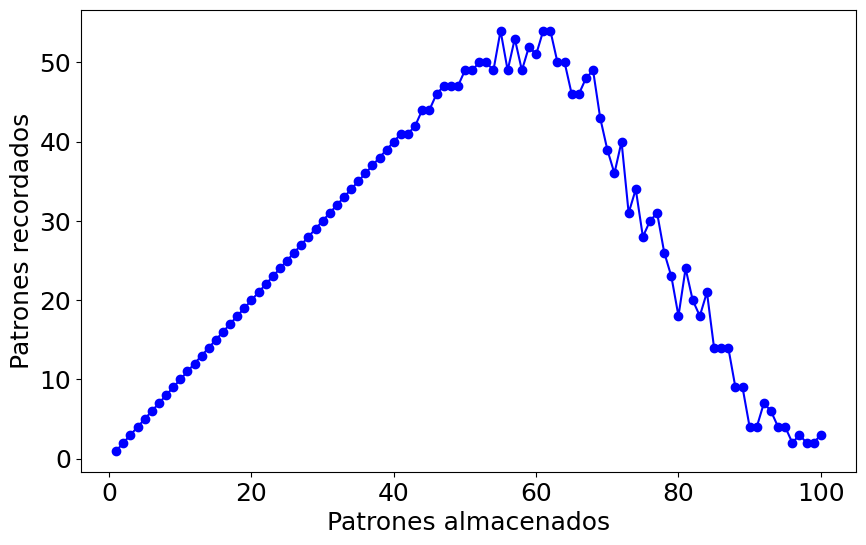

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Cargo los datos de memoria.txt, saltando la cabecera textual
p_1 = np.loadtxt("memoria.txt", skiprows=1)

# Extraigo las dos columnas
patrones_1 = p_1[:, 0]
patrones_recordados_1 = p_1[:, 1]

p_2 = np.loadtxt("memoria_2.txt", skiprows=1)

patrones_recordados_2 = p_2[:, 1]

p_3 = np.loadtxt("memoria_3.txt", skiprows=1)

patrones_recordados_3 = p_3[:, 1]

#Hago la media de las tres ejecuciones 

patrones = patrones_1
patrones_recordados = np.floor((patrones_recordados_1 + patrones_recordados_2 + patrones_recordados_3) / 3).astype(int)

print("Patrones almacenados:")
print(patrones)
print()
print("Media de los recordados:")
print(patrones_recordados)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(patrones, patrones_recordados, marker="o", color="blue")
ax.set_xlabel("Patrones almacenados",fontsize=18)
ax.set_ylabel("Patrones recordados",fontsize=18)
ax.tick_params(axis="both", labelsize=18)


plt.show()
